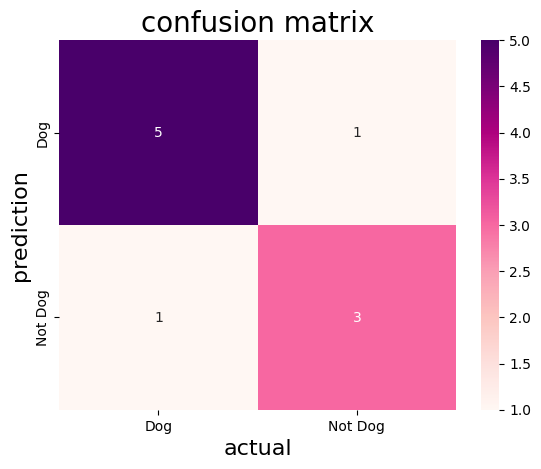

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
actual = np.array(
['Dog','Dog','Dog','Not Dog','Dog','Not Dog','Dog','Dog','Not Dog','Not Dog'])
predicted = np.array(
['Dog','Not Dog','Dog','Not Dog','Dog','Dog','Dog','Dog','Not Dog','Not Dog'])
conf_matrix=confusion_matrix(actual,predicted)
sns.heatmap(conf_matrix,annot=True,fmt='g',xticklabels=['Dog','Not Dog'],yticklabels=['Dog','Not Dog'],cmap='RdPu')
plt.ylabel("prediction",fontsize=16)
plt.xlabel("actual",fontsize=16)
plt.title("confusion matrix",fontsize=20)
plt.show()

accuracy: 0.9743589743589743
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


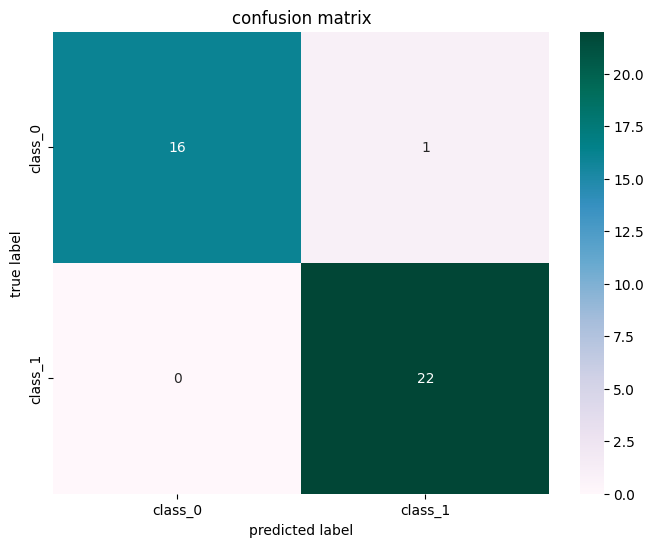

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix
wine=load_wine()
data=pd.DataFrame(data=wine.data,columns=wine.feature_names)
data['Target']=wine.target
data=data[data['Target']!=2]
x=data.drop('Target',axis=1)

y=data['Target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=DecisionTreeClassifier(random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
class_report = classification_report(y_test, y_pred,
target_names=wine.target_names[:2])
print("Classification Report:\n", class_report)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
conf_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='PuBuGn',xticklabels=wine.
target_names[:2],yticklabels=wine.target_names[:2])
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.title("confusion matrix")
plt.show()

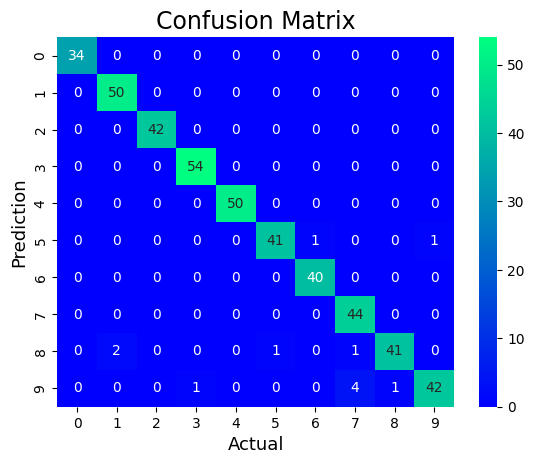

Accuracy : 0.9733333333333334


In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
X, y= load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25)
clf = RandomForestClassifier(random_state=23)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,
annot=True,
fmt='g',cmap="winter")
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

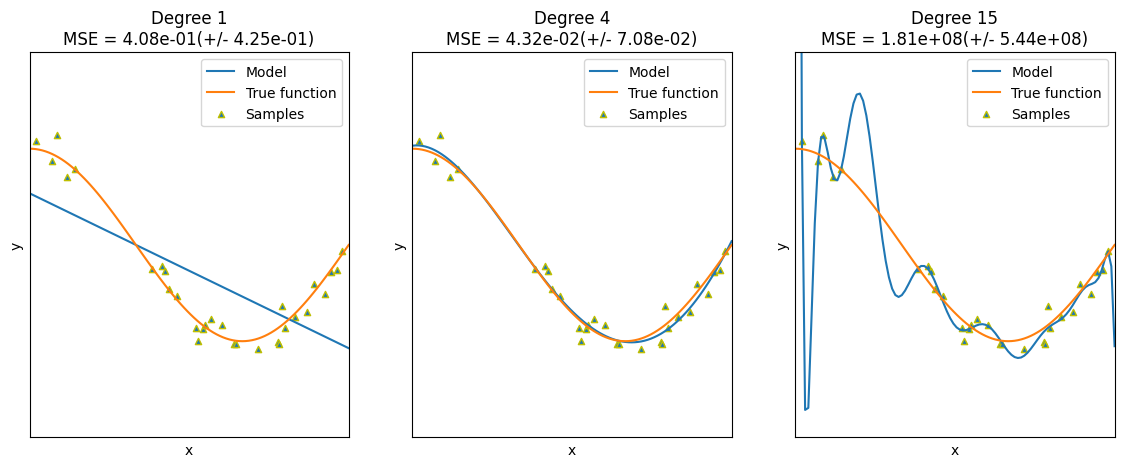

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)
    scores = cross_val_score(
        pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10
    )

    X_test = np.linspace(0, 1, 100)

    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor="y", s=20,marker="^", label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(
        """Degree {}
MSE = {:.2e}(+/- {:.2e})""".format(
            degrees[i], -scores.mean(), scores.std()
        )
    )
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Mean Squared Error on test set: 0.23


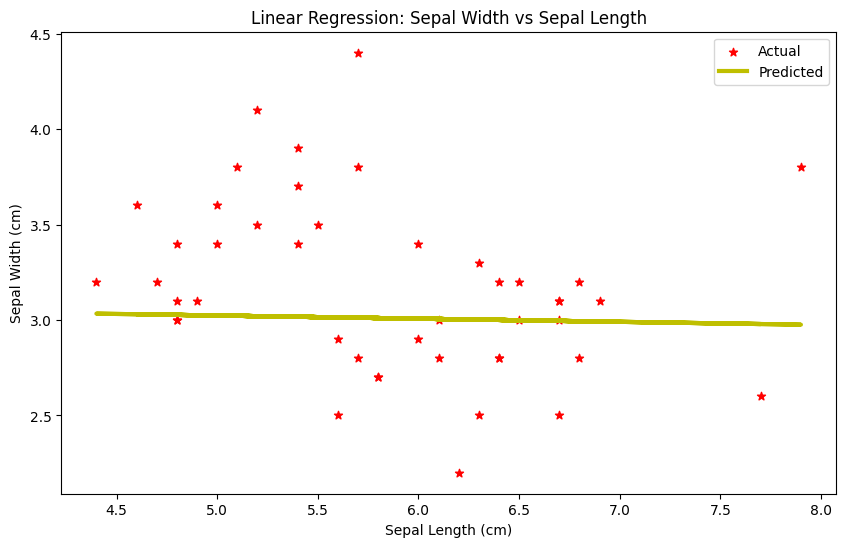

The predicted sepal width for sepal length [[5]]
is 3.02 cm


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
print(data.head())
X = data[['sepal length (cm)']]
y = data['sepal width (cm)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on test set: {mse:.2f}')
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='r',marker='*', label='Actual')
plt.plot(X_test, y_pred, color='y', linewidth=3, label='Predicted')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Linear Regression: Sepal Width vs Sepal Length')
plt.legend()
plt.show()

new_sample = pd.DataFrame([[5]], columns=['sepal length (cm)'])
predicted_width = model.predict(new_sample)
print(f"""The predicted sepal width for sepal length {new_sample.values.tolist()}
is {predicted_width[0]:.2f} cm""")

accuracy: 0.7037037037037037


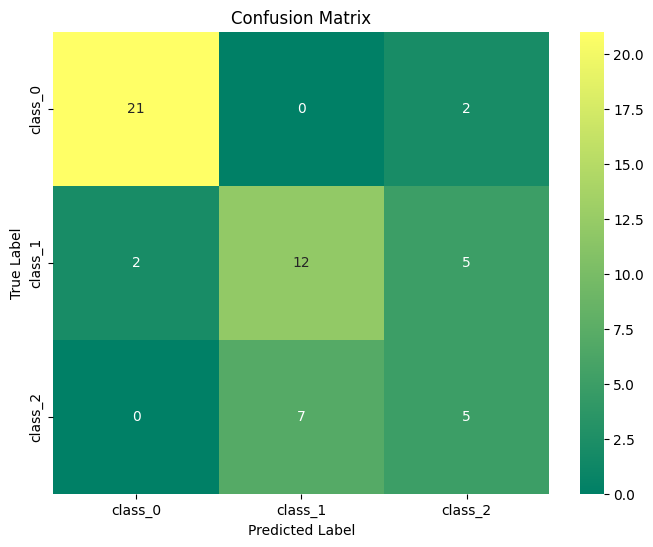

In [10]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
wine=load_wine()
data=pd.DataFrame(data=wine.data,columns=wine.feature_names)
data['Target']=wine.target
x=data.drop('Target',axis=1)
y=data['Target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='summer',
xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

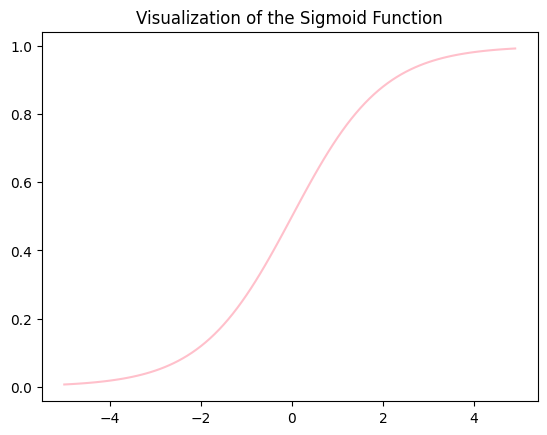

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1 / (1 + np.exp( - z))
plt.plot(np.arange(-5, 5, 0.1), sigmoid(np.arange(-5, 5, 0.1)),color='pink')
plt.title('Visualization of the Sigmoid Function')
plt.show()

accuracy: 0.9777777777777777


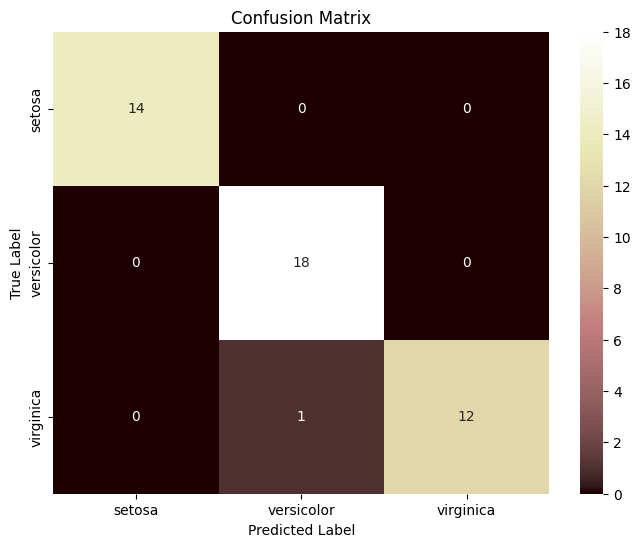

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='pink',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy: 0.9777777777777777


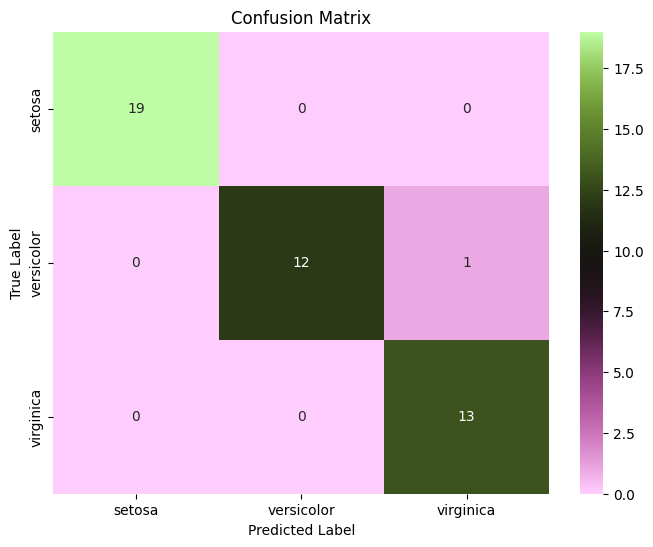

In [13]:
#naive bayes iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='vanimo',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy: 0.9666666666666667


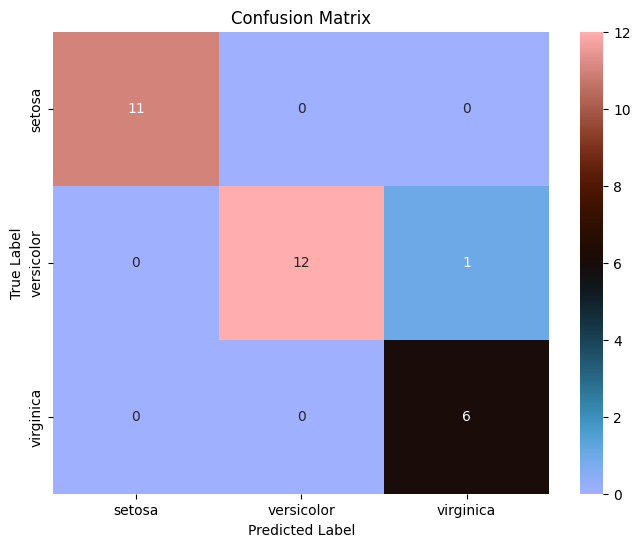

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)

data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)
model =LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='berlin',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

ex-11


accuracy: 0.9666666666666667


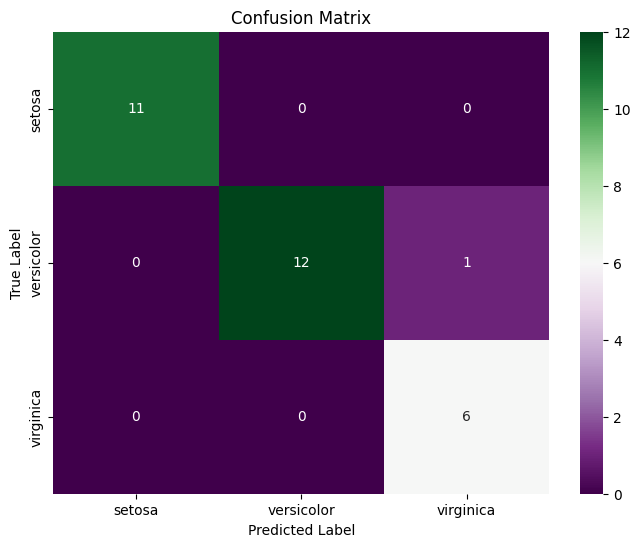

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)
model =DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PRGn',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

ex-12

accuracy: 0.9555555555555556


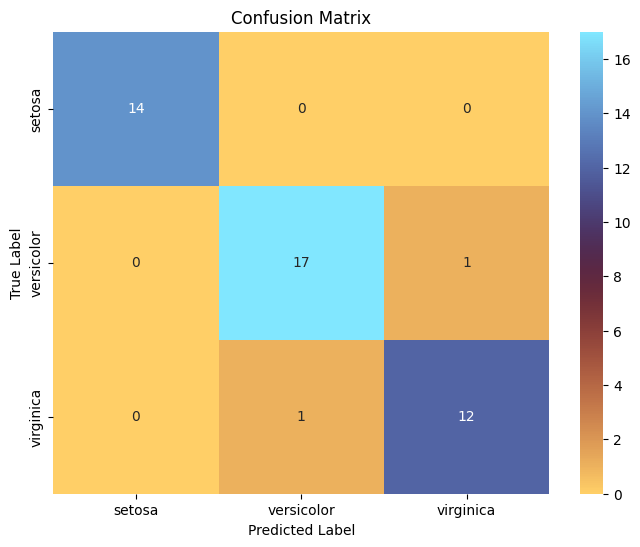

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=RandomForestClassifier(n_estimators=100,random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='managua',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')

plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

ex-13

accuracy: 0.9666666666666667


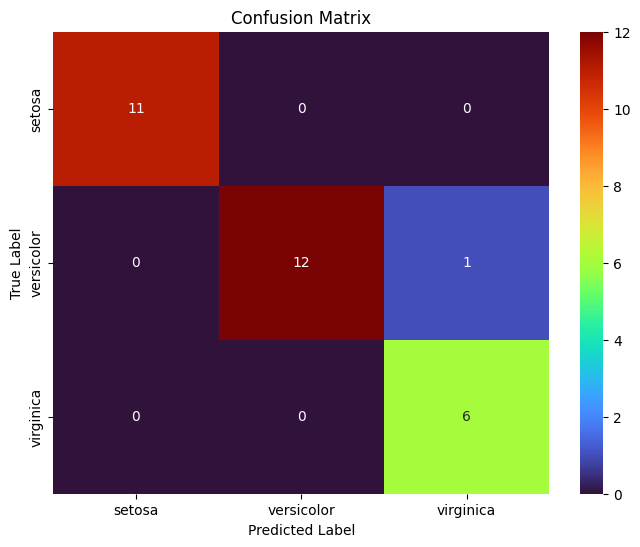

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
model=SVC(kernel='poly',random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='turbo',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

ex-14

Iteration 1: Cost 5031.3015, Weight 0.2174, Bias 1.3877
Iteration 101: Cost 185.5694, Weight 9.4592, Bias 60.3672
Iteration 201: Cost 100.3429, Weight 10.6849, Bias 68.1891
Iteration 301: Cost 98.8440, Weight 10.8474, Bias 69.2264
Iteration 401: Cost 98.8176, Weight 10.8690, Bias 69.3640


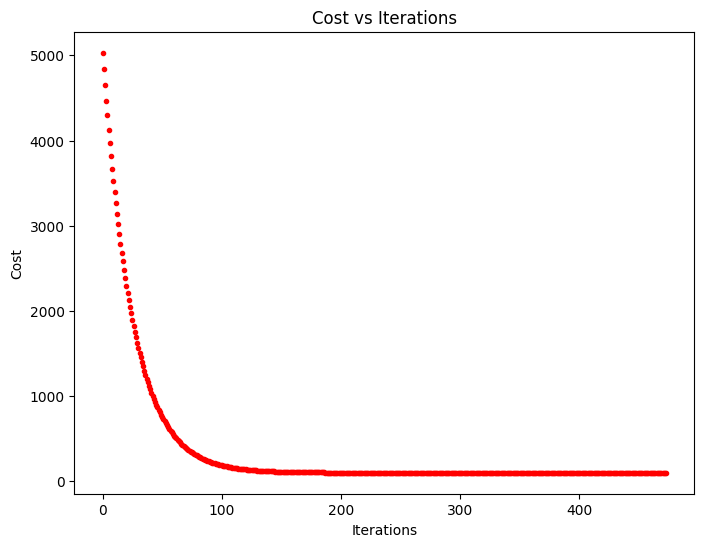

Estimated Weight: 10.8715, Estimated Bias: 69.3802


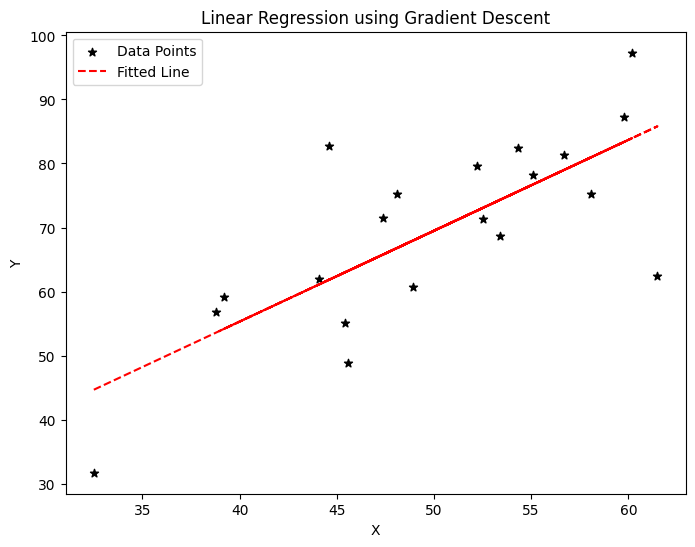

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def mean_squared_error(y_true, y_predicted):
    cost = np.sum((y_true - y_predicted)**2) / len(y_true)
    return cost

def gradient_descent(x, y, iterations=1000, learning_rate=0.01,
                     stopping_threshold=1e-6):
    current_weight = 0.0
    current_bias = 0.0

    n = float(len(x))
    costs = []
    previous_cost = None
    for i in range(iterations):
        y_predicted = current_weight * x + current_bias
        current_cost = mean_squared_error(y, y_predicted)
        if previous_cost and abs(previous_cost - current_cost) <= stopping_threshold:
            break
        previous_cost = current_cost
        costs.append(current_cost)
        weight_derivative = -(2/n) * sum(x * (y - y_predicted))
        bias_derivative = -(2/n) * sum(y - y_predicted)
        current_weight = current_weight - learning_rate * weight_derivative
        current_bias = current_bias - learning_rate * bias_derivative
        if i % 100 == 0:
            print(f"Iteration {i+1}: Cost {current_cost:.4f}, Weight {current_weight:.4f}, Bias {current_bias:.4f}")
    plt.figure(figsize=(8,6))
    plt.plot(range(len(costs)), costs, 'r.')
    plt.title("Cost vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.show()
    return current_weight, current_bias

def main():

    X = np.array([32.5, 53.4, 61.5, 47.4, 59.8, 55.1, 52.2, 39.2, 48.1, 52.5, 45.4,
                  54.3, 44.1, 58.1, 56.7, 48.9, 44.6, 60.2, 45.6, 38.8])
    Y = np.array([31.7, 68.7, 62.5, 71.5, 87.2, 78.2, 79.6, 59.1, 75.3, 71.3, 55.1,
                  82.4, 62.0, 75.3, 81.4, 60.7, 82.8, 97.3, 48.8, 56.8])
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X.reshape(-1, 1)).flatten()
    estimated_weight, estimated_bias = gradient_descent(X_normalized, Y,
                                                        iterations=2000, learning_rate=0.01)
    print(f"Estimated Weight: {estimated_weight:.4f}, Estimated Bias: {estimated_bias:.4f}")
    Y_pred = estimated_weight * X_normalized + estimated_bias
    plt.figure(figsize=(8,6))
    plt.scatter(X, Y, color='black', label='Data Points',marker='*')
    plt.plot(X, Y_pred, color='red', linestyle='--', label='Fitted Line')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Linear Regression using Gradient Descent")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

15

--2026-08-22 04:52:27--  https://picsum.photos/id/237/800/600
Resolving picsum.photos (picsum.photos)... 172.67.74.163, 104.26.4.30, 104.26.5.30, ...
Connecting to picsum.photos (picsum.photos)|172.67.74.163|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/237/800/600.jpg?hmac=KK6IftaxyI6scjoxeWUHr2AWr-7RQuExLH9vY4hSR6w [following]
--2026-08-22 04:52:28--  https://fastly.picsum.photos/id/237/800/600.jpg?hmac=KK6IftaxyI6scjoxeWUHr2AWr-7RQuExLH9vY4hSR6w
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71743 (70K) [image/jpeg]
Saving to: ‘dog_image.jpg’

dog_image.jpg       100%[===================>]  70.06K  --.-KB/s    in 0.01s   

2026-08-22 04:52:28 (5.42 MB/s) - ‘dog_image.jpg’ saved [71743/71743]



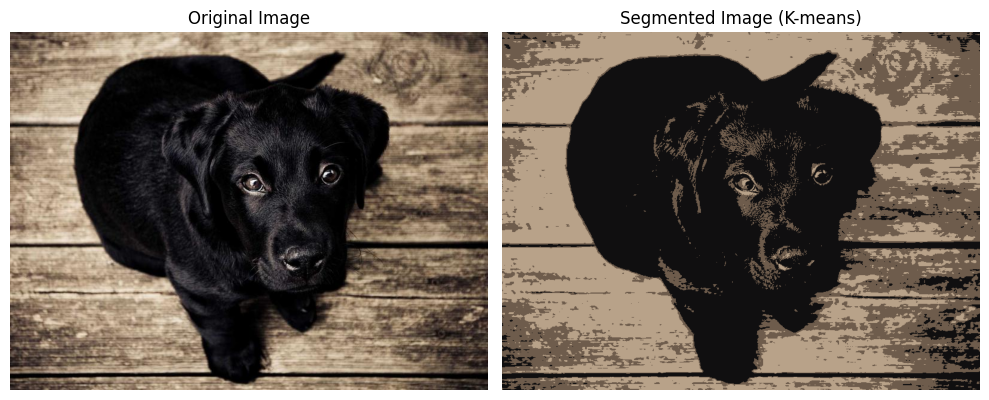

In [25]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Alternative way to load image without Drive:
# Download an image from a URL
!wget "https://picsum.photos/id/237/800/600" -O dog_image.jpg

img = cv2.imread('dog_image.jpg') # Load the downloaded image

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the file path.")
else:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixels = np.float32(rgb_img.reshape((-1, 3)))
    criteria = (cv2.TERM_CRITERIA_EPS +
                cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    K = 3
    _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10,
                                    cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented_img = centers[labels.flatten()].reshape(rgb_img.shape)
    plt.figure(figsize=(10, 5))
    plt.subplot(121)
    plt.imshow(rgb_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(segmented_img)
    plt.title('Segmented Image (K-means)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

16

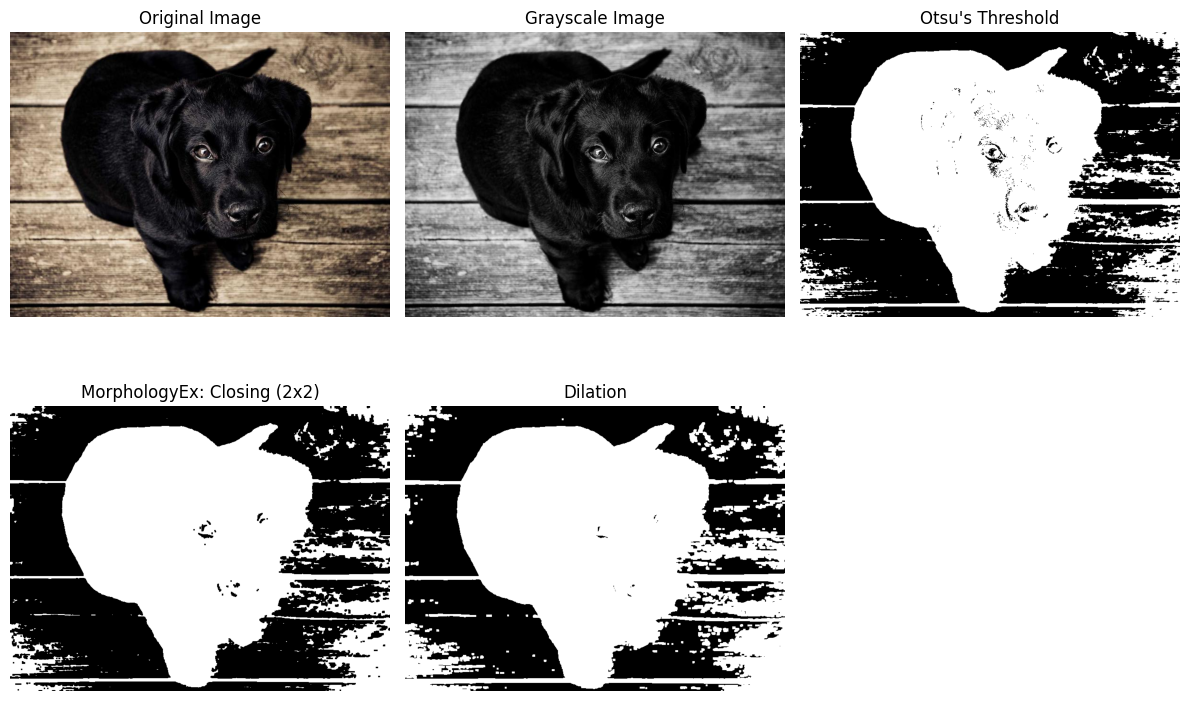

In [29]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from google.colab import drive
# Mount Google Drive if not already mounted
try:
    drive.mount('/content/drive')

except:
    pass # Drive is already mounted
# For Colab: !wget https://example.com/cataract_image.jpg -O image.jpg
img = cv2.imread('dog_image.jpg') # Load the locally downloaded image

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the file path.")
else:
    b, g, r = cv2.split(img)
    rgb_img = cv2.merge([r, g, b])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV +
                                cv2.THRESH_OTSU)
    kernel = np.ones((2, 2), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel,
                               iterations=2)
    sure_bg = cv2.dilate(closing, kernel, iterations=3)
    plt.figure(figsize=(12, 8))
    plt.subplot(231); plt.imshow(rgb_img); plt.title("Original Image");
    plt.axis('off')
    plt.subplot(232); plt.imshow(gray, 'gray'); plt.title("Grayscale Image");
    plt.axis('off')
    plt.subplot(233); plt.imshow(thresh, 'gray'); plt.title("Otsu's Threshold");
    plt.axis('off')
    plt.subplot(234); plt.imshow(closing, 'gray'); plt.title("MorphologyEx: Closing (2x2)");
    plt.axis('off')
    plt.subplot(235); plt.imshow(sure_bg, 'gray'); plt.title("Dilation");
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.imsave('dilation.png', sure_bg)

17

Accuracy: 1.00


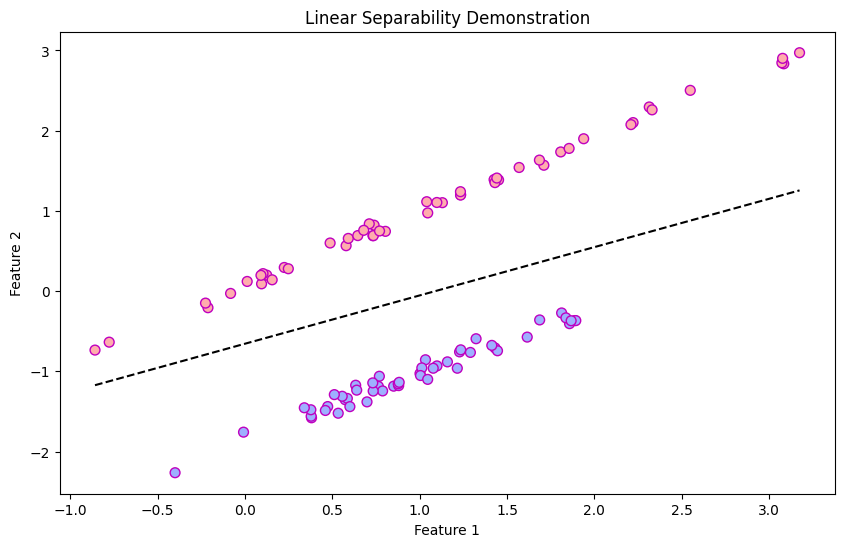

2

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
n_redundant=0, n_clusters_per_class=1, random_state=42)
model = LogisticRegression()

model.fit(X, y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.2f}")
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='berlin', edgecolor='m', s=50)
coef = model.coef_[0]
intercept = model.intercept_
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = - (coef[0] * x_vals + intercept) / coef[1]
plt.plot(x_vals, y_vals, 'k--')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear Separability Demonstration')
plt.show()
i

18

Training the Neural Network...
Training complete.

Accuracy: 0.87

Confusion Matrix:
[[27  7]
 [ 1 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        34
           1       0.78      0.96      0.86        26

    accuracy                           0.87        60
   macro avg       0.87      0.88      0.87        60
weighted avg       0.88      0.87      0.87        60



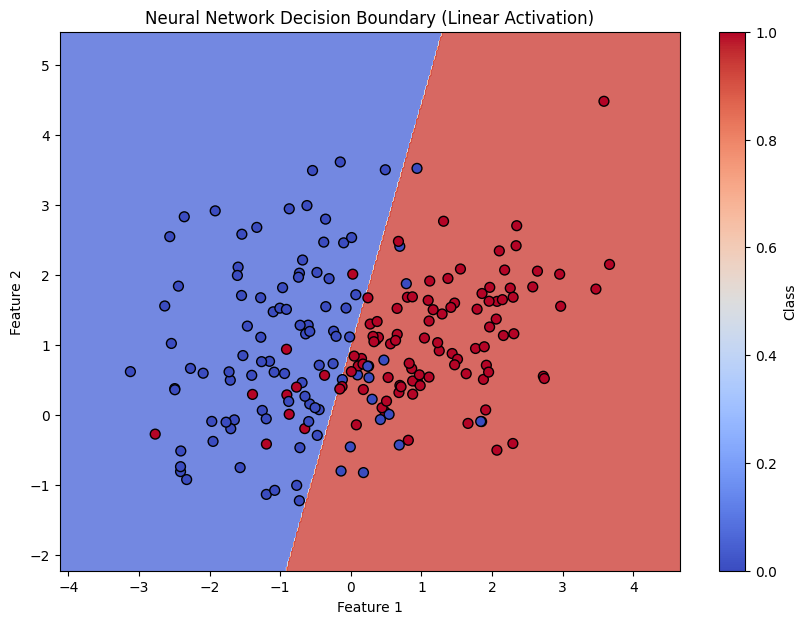

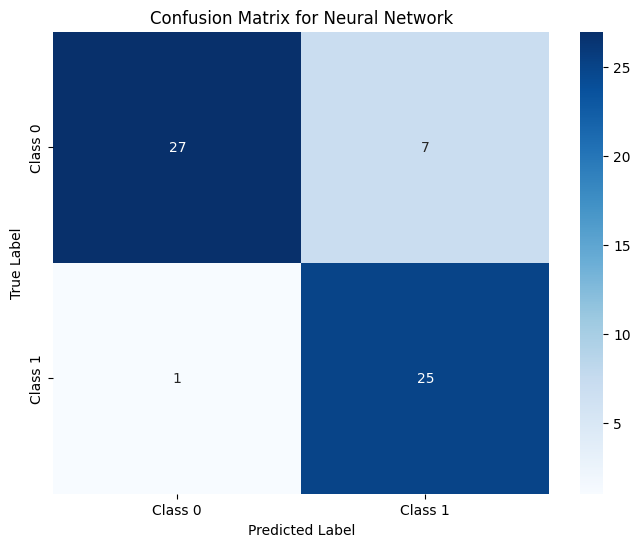

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Generate a synthetic dataset for binary classification
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42, n_classes=2)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Define the MLPClassifier (Neural Network)
#    - hidden_layer_sizes=(3, 3): Two hidden layers, each with 3 neurons
#    - activation='identity': Linear activation function
#    - learning_rate_init=0.03: Initial learning rate
#    - max_iter=1000: Maximum number of iterations for the solver to converge
#    - random_state=42: For reproducibility
#    - solver='sgd': Stochastic Gradient Descent optimizer

model = MLPClassifier(hidden_layer_sizes=(3, 3), activation='identity',
                      learning_rate_init=0.03, max_iter=1000, random_state=42,
                      solver='sgd', verbose=False)

# 4. Train the model
print("Training the Neural Network...")
model.fit(X_train, y_train)
print("Training complete.")

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# 7. Visualize the decision boundary
plt.figure(figsize=(10, 7))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Neural Network Decision Boundary (Linear Activation)')
plt.colorbar(label='Class')
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Neural Network')
plt.show()

19

Training the Neural Network for circular data...
Training complete.

Accuracy for circular data: 0.45

Confusion Matrix for circular data:
[[10 22]
 [11 17]]

Classification Report for circular data:
              precision    recall  f1-score   support

           0       0.48      0.31      0.38        32
           1       0.44      0.61      0.51        28

    accuracy                           0.45        60
   macro avg       0.46      0.46      0.44        60
weighted avg       0.46      0.45      0.44        60



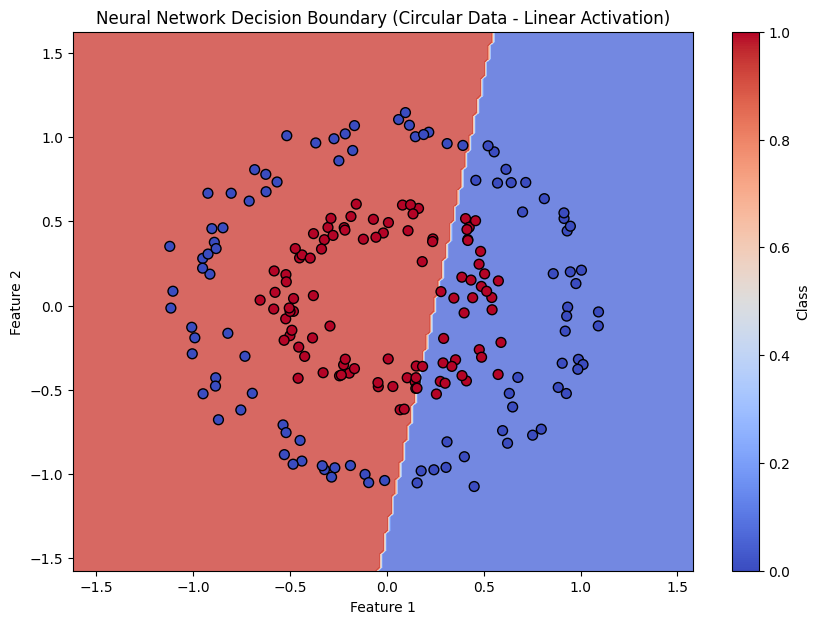

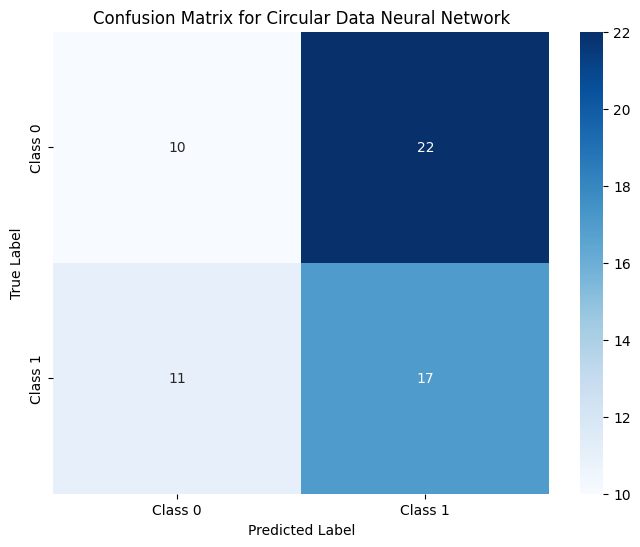

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Generate a synthetic circularly separable dataset
#    factor: Scale factor between inner and outer circle.
#    noise: Standard deviation of Gaussian noise added to the data.
X_circ, y_circ = make_circles(n_samples=200, factor=0.5, noise=0.08, random_state=42)

# 2. Split the data into training and testing sets
X_train_circ, X_test_circ, y_train_circ, y_test_circ = train_test_split(X_circ, y_circ, test_size=0.3, random_state=42)

# 3. Define the MLPClassifier (Neural Network) with specified parameters
#    - hidden_layer_sizes=(3, 3): Two hidden layers, each with 3 neurons
#    - activation='identity': Linear activation function
#    - learning_rate_init=0.03: Initial learning rate
#    - max_iter=2000: Increased max_iter for potentially harder convergence
#    - random_state=42: For reproducibility
#    - solver='sgd': Stochastic Gradient Descent optimizer
model_circ = MLPClassifier(hidden_layer_sizes=(3, 3), activation='identity',
                           learning_rate_init=0.03, max_iter=2000, random_state=42,
                           solver='sgd', verbose=False)

# 4. Train the model
print("Training the Neural Network for circular data...")
model_circ.fit(X_train_circ, y_train_circ)
print("Training complete.")

# 5. Make predictions
y_pred_circ = model_circ.predict(X_test_circ)

# 6. Evaluate the model
accuracy_circ = accuracy_score(y_test_circ, y_pred_circ)
conf_matrix_circ = confusion_matrix(y_test_circ, y_pred_circ)
class_report_circ = classification_report(y_test_circ, y_pred_circ)

print(f"\nAccuracy for circular data: {accuracy_circ:.2f}")
print("\nConfusion Matrix for circular data:")
print(conf_matrix_circ)
print("\nClassification Report for circular data:")
print(class_report_circ)

# 7. Visualize the decision boundary
plt.figure(figsize=(10, 7))

x_min, x_max = X_circ[:, 0].min() - 0.5, X_circ[:, 0].max() + 0.5
y_min, y_max = X_circ[:, 1].min() - 0.5, X_circ[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))

Z_circ = model_circ.predict(np.c_[xx.ravel(), yy.ravel()])
Z_circ = Z_circ.reshape(xx.shape)

plt.contourf(xx, yy, Z_circ, alpha=0.8, cmap='coolwarm')
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, s=50, edgecolors='k', cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Neural Network Decision Boundary (Circular Data - Linear Activation)')
plt.colorbar(label='Class')
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_circ, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Circular Data Neural Network')
plt.show()

20

Training the Neural Network for multi-class data...
Training complete.

Accuracy for multi-class data: 0.88

Confusion Matrix for multi-class data:
[[22  5  0]
 [ 2 36  0]
 [ 4  0 21]]

Classification Report for multi-class data:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        27
           1       0.88      0.95      0.91        38
           2       1.00      0.84      0.91        25

    accuracy                           0.88        90
   macro avg       0.89      0.87      0.87        90
weighted avg       0.88      0.88      0.88        90



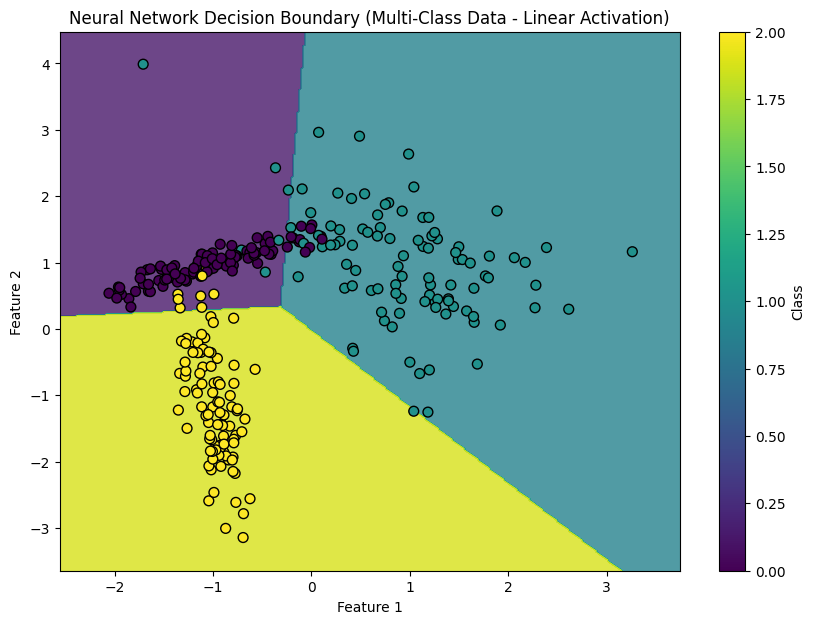

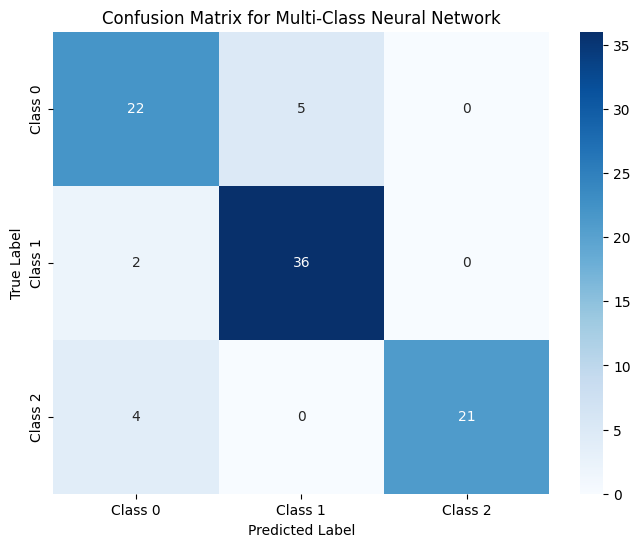

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Generate a synthetic multi-class dataset (3 classes)
X_multi, y_multi = make_classification(n_samples=300, n_features=2, n_informative=2,
                                       n_redundant=0, n_clusters_per_class=1,
                                       n_classes=3, random_state=42)

# 2. Split the data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

# 3. Define the MLPClassifier for multi-class
#    - hidden_layer_sizes=(2, 2): Two hidden layers, each with 2 neurons
#    - activation='identity': Linear activation function
#    - learning_rate_init=0.01: Initial learning rate
#    - max_iter=2000: Increased max_iter for potentially harder convergence with linear activation
#    - random_state=42: For reproducibility
#    - solver='sgd': Stochastic Gradient Descent optimizer
model_multi = MLPClassifier(hidden_layer_sizes=(2, 2), activation='identity',
                            learning_rate_init=0.01, max_iter=2000, random_state=42,
                            solver='sgd', verbose=False)

# 4. Train the model
print("Training the Neural Network for multi-class data...")
model_multi.fit(X_train_multi, y_train_multi)
print("Training complete.")

# 5. Make predictions
y_pred_multi = model_multi.predict(X_test_multi)

# 6. Evaluate the model
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
conf_matrix_multi = confusion_matrix(y_test_multi, y_pred_multi)
class_report_multi = classification_report(y_test_multi, y_pred_multi)

print(f"\nAccuracy for multi-class data: {accuracy_multi:.2f}")
print("\nConfusion Matrix for multi-class data:")
print(conf_matrix_multi)
print("\nClassification Report for multi-class data:")
print(class_report_multi)

# 7. Visualize the decision boundary
plt.figure(figsize=(10, 7))

x_min, x_max = X_multi[:, 0].min() - 0.5, X_multi[:, 0].max() + 0.5
y_min, y_max = X_multi[:, 1].min() - 0.5, X_multi[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z_multi = model_multi.predict(np.c_[xx.ravel(), yy.ravel()])
Z_multi = Z_multi.reshape(xx.shape)

# Plot the decision boundaries
plt.contourf(xx, yy, Z_multi, alpha=0.8, cmap='viridis')
# Plot the training points
plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, s=50, edgecolors='k', cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Neural Network Decision Boundary (Multi-Class Data - Linear Activation)')
plt.colorbar(label='Class')
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(model_multi.n_outputs_)],
            yticklabels=[f'Class {i}' for i in range(model_multi.n_outputs_)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multi-Class Neural Network')
plt.show()